# 01 Obt Feature Analysis

This notebook is to analyze the OBT data

## Section 0: Setup

In [11]:
# ======================================================
# Section 0 (Cell 1/1): Setup
# ======================================================
# Requirements (local):
# - Postgres is running and `analysis.analysis_orders_obt` exists
# - DB credentials are provided via env vars (see `.env.example`)
# - Figures will be saved under `outputs/figures/`

import os
import sys
from pathlib import Path
from datetime import datetime, timezone, timedelta

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sqlalchemy import create_engine

try:
    from dotenv import load_dotenv
except Exception:  # pragma: no cover
    load_dotenv = None

if load_dotenv is not None:
    load_dotenv()

# Timezone anchoring for reproducibility
TZ_UTC8 = timezone(timedelta(hours=8))
run_ts_utc8 = datetime.now(TZ_UTC8).strftime('%Y-%m-%d %H:%M:%S %z')
print(f'[UTC+8] Run timestamp: {run_ts_utc8}')

# Project root resolution (avoid hardcoding)
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Figures output
figures_dir = project_root / 'outputs' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
print(f'Figures will be saved to: {figures_dir}')

# Build engine (prefer DATABASE_URL, fallback to discrete vars)
database_url = os.getenv('DATABASE_URL')
if database_url:
    engine = create_engine(database_url)
else:
    USER = os.getenv('DB_USER')
    PASSWORD = os.getenv('DB_PASS')
    HOST = os.getenv('DB_HOST', 'localhost')
    PORT = os.getenv('DB_PORT', '5432')
    DB = os.getenv('DB_NAME')

    missing = [k for k, v in {'DB_USER': USER, 'DB_PASS': PASSWORD, 'DB_NAME': DB}.items() if not v]
    if missing:
        raise RuntimeError('Missing required env vars (or set DATABASE_URL): ' + ', '.join(missing))

    engine = create_engine(f'postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')

df = pd.read_sql('SELECT * FROM analysis.analysis_orders_obt', engine)
assert len(df) > 0, 'Loaded OBT is empty'

# Basic check
df.shape, df[['delay_days','review_score','has_review','gmv']].describe()


[UTC+8] Run timestamp: 2026-02-28 21:39:30 +0800
Figures will be saved to: e:\Work\MyCode\ecommerce-analytics-pipeline\outputs\figures


((96470, 27),
          delay_days  review_score    has_review           gmv
 count  96470.000000  95824.000000  96470.000000  96470.000000
 mean     -11.178126      4.154210      0.993304    159.853663
 std       10.184354      1.286027      0.081557    218.820405
 min     -146.016123      1.000000      0.000000      0.000000
 25%      -16.244065      4.000000      1.000000     61.880000
 50%      -11.948102      5.000000      1.000000    105.280000
 75%       -6.389815      5.000000      1.000000    176.330000
 max      188.975081      5.000000      1.000000  13664.080000)

## Section 1: Correlation Coefficient

In [12]:
# ======================================================
# Section 1 (Cell 1/1): Correlation Coefficient
# ======================================================
# (Exploratory) 先计算延迟交付时间和评分的相关系数
# 注意: 相关性不等于因果. 可能存在误差, Pearson/Spearman 相关系数只是粗糙近似

# ---------------------------------
# 0) Compuse Pearson/Spearman Correlation Coefficient (OLD)
# ----------------------------------
# Logic: 该部分用 delay_days (提前送达是负数)来计算相关系数,会导致数值绝对值偏小
"""
corr_p = df[["delay_days","review_score"]].corr(method="pearson").iloc[0,1]
corr_s = df[["delay_days","review_score"]].corr(method="spearman").iloc[0,1]
print(f"Pearson corr(delay,review) = {corr_p:.4f}")
print(f"Spearman corr(delay,review) = {corr_s:.4f}")
"""

# ----------------------------------
# 1) Compuse Pearson/Spearman Correlation Coefficient (NEW)
# ----------------------------------
# Logic: 将提前、按时送达都设为 0 (截断),从而得到能正确反映延迟交付天数和评分的相关系数
df["delay_days_clipped"] = df["delay_days"].clip(lower=0)

# 有些订单可能没有评论, 列出具体的订单数 ( 有评论的订单/ 总订单)
df_reviewed = df[df["has_review"] == 1].copy()
print(f"Review coverage (has_review=1): {len(df_reviewed) / len(df):.2%} ({len(df_reviewed)}/{len(df)})")

corr_p = df_reviewed[["delay_days_clipped","review_score"]].corr(method="pearson").iloc[0,1]
corr_s = df_reviewed[["delay_days_clipped","review_score"]].corr(method="spearman").iloc[0,1]
print(f"Pearson corr(delay,review) = {corr_p:.4f}")
print(f"Spearman corr(delay,review) = {corr_s:.4f}")

print(df_reviewed.groupby("delivery_status")["review_score"].agg(["count","mean","median"]))

Review coverage (has_review=1): 99.33% (95824/96470)
Pearson corr(delay,review) = -0.2719
Spearman corr(delay,review) = -0.2999
                 count      mean  median
delivery_status                         
Late_Severe       5025  1.934527     1.0
Late_Small        2636  3.763278     4.0
OnTime           88163  4.292413     5.0


### Section 1 Summary

**Workflow**: 计算延迟交付时间 (``delay_days``) 和评分 (``review_score``) 的 Pearson/Spearman 相关系数

1) **截断负数**：延迟交付时间存在负数 (表示提前送达)
    - "无效变异": 提前1天和提前20天送达, 用户都是很开心(5分评价),因为5分就是最高分了.所以在提前(小于零)的区间里,无论交付时间如何变化,评分几乎是不变的
    - "计算机制": Spearman 相关系数是基于排名计算相关系数的, 会给提前的订单按顺序排名。如果不进行截断, Spearman 发现负数部分的排名剧烈变化,但是评分却几乎不变, 会认为这部分数据没有相关性, 最终使相关系数减小。

**Core Figures**
- 延迟交付时间和评分的 Spearman/Pearson 相关系数均为负, 呈现弱到中等程度的相关关系。
- Spearman 相关系数绝对值大于 Pearson, 这表明延迟交付时间和评分的相关关系更偏向非线性相关。


**Insights**:
- "提前送达的无用功": 只要延迟交付时间属于 `Ontime` 的区间, 中位数为 `5.0`, 这表明提前送达的时间对评分的影响是不明显的
- "愤怒悬崖": 只要延迟交付时间从 `Late_Small` 变成 `late_Severe`,评分就会从 `4.0` 骤降至 `1.0` (这也侧面印证了延迟交付时间和评分的非线性相关性)

**Business Translation**:
- **资源置换**: 既然提前送达对评分的影响不明显, 那么应减少或停止对"提前送达"的过度投入
- **黄金救援期**: 重点监测 `Late_Small` 状态的订单,只要避免变成 `Late_Severe` , 就能挽回近 3 分的满意度

---

## Section 2: Feature Analysis Model

In [13]:
# ======================================================
# Section 2 (Cell 1/1): Feature Analysis Model Construction
# ======================================================

# ----------------------------------------------------
# 1) Indicator Preprocess (bad review label, purchase month)
# ----------------------------------------------------
# Logit: Generate bad review indicator (bad review = 1, non-bad review = 0)

# Bad review is only defined when a review exists (avoid treating missing as negative)
model_base_df = df[df["has_review"] == 1].copy()

# Bad review: ratings <= 2
model_base_df["bad_review"] = (model_base_df["review_score"] <= 2).astype(int)

# Truncate the purchase time by month
model_base_df["purchase_month"] = pd.to_datetime(model_base_df["purchase_ts"]).dt.to_period('M').astype(str)


# ----------------------------------------------------
# 2) Feature Selection
# ----------------------------------------------------
# Strategy:
#   1. 保留核心数值指标 + 1 个核心分类指标 (支付方式)
#   2. 去掉高纬度稀疏特征 (customer_state, purchase_month)
# Motivation: 避免完全分离, 保持收敛稳定

# The annotation content is former feature indicators
#features = ["delay_days","gmv","items_cnt","freight_value","customer_state","payment_method","purchase_month"]

# Seperate numeric/categorical features
features_num = ["delay_days","gmv","items_cnt","freight_value"]
features_cat = ["payment_method"]
model_df = model_base_df[features_num + features_cat + ["bad_review"]].dropna()

# -------------------------------
# 3) Standardization (z-score)
# -------------------------------
# Logit: 将所有特征标准化, 拉齐到同一水平 (均值为0,标准差为1) 
# Business: 系数大小直接代表"重要性",方便直接比较各个系数

for c in features_num:
    # Standardization = (Original - Mean) / Standard Deviation
    model_df[c] = (model_df[c] - model_df[c].mean()) / model_df[c].std()

# -------------------------------
# 4) One-Hot Encoding
# -------------------------------
X = pd.get_dummies(model_df[features_num + features_cat],drop_first=True)

# Clean up the column names (avoid statmodels error)
X.columns = [c.replace(' ','_').replace('-','_') for c in X.columns]
X = X.astype(float)
y= model_df["bad_review"].astype(float)

# 
X_const = sm.add_constant(X)

# ------------------------------------
# 5) Construct Model (BFGS)
# ------------------------------------
try:
    logit = sm.Logit(y, X_const).fit(method='bfgs', maxiter=1000)
    
    print(logit.summary().as_text()[:2000])
    
    # Compute Odds Ratio (Probability Ratio)
    print("\n========== 业务解读(Odds Ratio) ==========")
    params = logit.params
    conf = logit.conf_int()
    conf['Odds Ratio'] = params
    conf.columns = ['5%', '95%', 'Odds Ratio']
    # 取指数 np.exp() 将 Log-Odds 还原为倍数关系
    print(np.exp(conf).sort_values(by="Odds Ratio", ascending=False))
    
except Exception as e:
    print(f"Optimization failed: {e}")

Optimization terminated successfully.
         Current function value: 0.344425
         Iterations: 59
         Function evaluations: 60
         Gradient evaluations: 60
                           Logit Regression Results                           
Dep. Variable:             bad_review   No. Observations:                95824
Model:                          Logit   Df Residuals:                    95814
Method:                           MLE   Df Model:                            9
Date:                Sat, 28 Feb 2026   Pseudo R-squ.:                  0.1018
Time:                        21:39:34   Log-Likelihood:                -33004.
converged:                       True   LL-Null:                       -36744.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

### Section 2 Summary

**Workflow**: 对各类特征数据进行预处理 (坏评标签, 按月份截断, 特征选择, 标准化, one-hot编码), 随后建立拟合模型, 计算出各个特征的 Odds Ratio 系数

**Core Figures**
- 延迟交付时间的 Odds Ratio 最高 (2.2048), 然后是使用了优惠券的支付方式 (1.3576), 其次是购买物品的数量 (1.3061)
- 其余特征的 Odds Ratio 均接近 1, 可以认为这些特征对评分的影响不明显

---

## Section 3: Model Evaluation

In [14]:
# ======================================================
# Section 3 (Cell 1/1): Model Evaluation
# ======================================================
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

# 获取预测概率
# statsmodels的predict返回的是概率值 (0到1之间)
y_pred_prob = logit.predict(X_const)

# 将概率转换为0/1标签 (通常以0.5为阈值)
y_pred = (y_pred_prob > 0.5).astype(int)

# 计算核心指标
auc_score = roc_auc_score(y,y_pred_prob)

print(f"========== 模型评估报告 ==========")
print(f"AUC Score: {auc_score:.4f} (衡量模型区分好坏评的能力)")
print("-" * 30)
print("详细分类报告 (Classification Report):")

# target_names 对应 [0:非差评, 1:差评]
print(classification_report(y, y_pred, target_names=['Not Bad', 'Bad Review']))

========== 模型评估报告 ==========
AUC Score: 0.6987 (衡量模型区分好坏评的能力)
------------------------------
详细分类报告 (Classification Report):
              precision    recall  f1-score   support

     Not Bad       0.88      0.99      0.93     83514
  Bad Review       0.68      0.09      0.16     12310

    accuracy                           0.88     95824
   macro avg       0.78      0.54      0.55     95824
weighted avg       0.86      0.88      0.83     95824



### Section 3 Summary

**Overall Performance**:
- AUC = 0.6987：模型具备一定区分能力，能够较好区分正常评论与差评。
- Accuracy = 0.88：整体预测较稳定，适合作为初版 baseline。

**Class-Level Performance**:
- **Not Bad**: Precision = 0.88, Recall = 0.99, F1 = 0.93
- **Bad Review**: Precision = 0.68, Recall = 0.09, F1 = 0.16

**Core Interpretation**:
- 模型对多数类 Not Bad 的识别效果较强，说明其在大规模评论过滤场景下具备较好的稳定性。
- 对 Bad Review，当前模型呈现出 “**高置信度识别、偏保守召回**” 的特征：虽然召回率较低，但预测为差评的样本具有一定准确性。
- 整体来看，该模型已经建立起可用的差评识别 baseline，适合作为后续优化的起点。

**Business Translation**:
- 该模型适合用于**评论初筛、风险样本预警、人工审核前置过滤**等场景。
- 当前优势在于整体稳定性较好，且能够识别一批相对高置信度的差评样本。
- 当前局限在于对少数类差评的覆盖还不充分，后续可通过类别不平衡处理、阈值调整等方式进一步提升召回。

**Key Takeaway**:
- 这是一个**整体可用、区分能力初步成立的 baseline 模型**；
- 优势在于对正常评论识别稳定、对高风险差评具备一定捕捉能力；
- 不足在于差评召回偏低，但这也明确了后续优化方向。

---

## Section 4: Visualization

.png saved: e:\Work\MyCode\ecommerce-analytics-pipeline\outputs\figures\fig_01_roc_curve.png


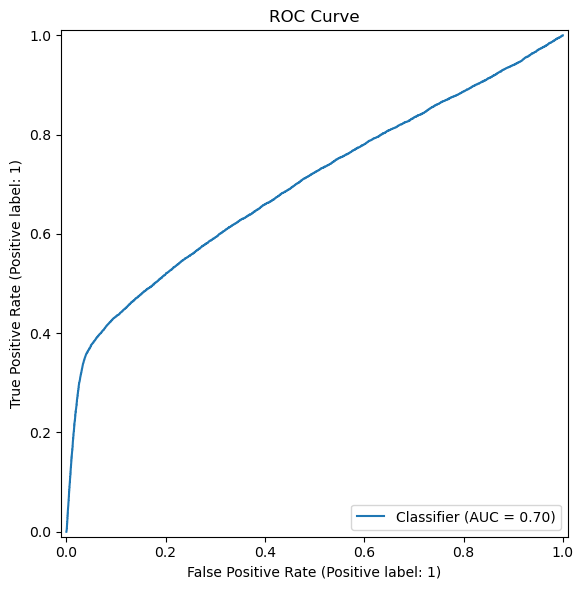

.png saved: e:\Work\MyCode\ecommerce-analytics-pipeline\outputs\figures\fig_01_odds_ratio.png


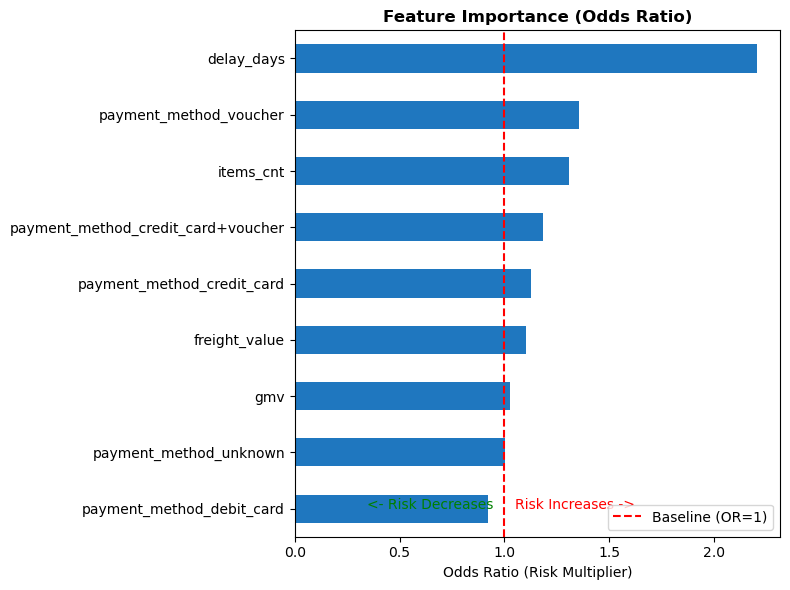

In [15]:
# ======================================================
# Section 4 (Cell 1/1): Visualization
# ======================================================

from pathlib import Path

# Keep this cell runnable standalone
if 'figures_dir' not in globals():
    project_root = Path.cwd()
    if project_root.name == 'notebooks':
        project_root = project_root.parent
    figures_dir = project_root / 'outputs' / 'figures'
    figures_dir.mkdir(parents=True, exist_ok=True)
    print(f'Figures will be saved to: {figures_dir}')

# -----------------------------
# 1) Visualize ROC Curve and AUC
# -----------------------------
# Logit: 直接调用库
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y, y_pred_prob, ax=ax)
ax.set_title('ROC Curve')
plt.tight_layout()
out = figures_dir / 'fig_01_roc_curve.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'.png saved: {out}')
plt.show()

# ----------------------------
# 2) Visualize Odds Ratio
# ----------------------------

# 以下注释代码为错误的旧代码
"""
plot_data = conf["Odds Ratio"].drop("const").sort_values()
plot_data.plot(kind="barh",figsize=(8,5))
plt.axvline(x=1,color="red",linestyle="--")
plt.title("Feature Importance (Odds Ratio)")
plt.show()
"""

# logit.params 是系数 (Coef), np.exp(logit.params) 才是OR
or_data = np.exp(logit.params).drop("const").sort_values()

fig,ax = plt.subplots(figsize=(8,6))

or_data.plot(kind="barh",color="#1f77bf",ax=ax)

# OR 的基准线是 1
ax.axvline(x=1,color="red",linestyle="--",linewidth=1.5,label="Baseline (OR=1)")

# 相关标注
ax.set_title('Feature Importance (Odds Ratio)', fontsize=12, fontweight='bold')
ax.set_xlabel('Odds Ratio (Risk Multiplier)')
ax.legend(loc='lower right')

# 标注解释
plt.text(1.05, 0, 'Risk Increases ->', color='red', fontsize=10)
plt.text(0.95, 0, '<- Risk Decreases', color='green', fontsize=10, ha='right')

plt.tight_layout()
out = figures_dir / 'fig_01_odds_ratio.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'.png saved: {out}')
plt.show()


### Section 4 Smmary

**Model Type**: 对于差评风险监测的Logistic Regression 模型

**Overall Performance**:
* **ROC-AUC ≈ 0.70**：模型具备基础区分能力，可作为差评风险识别的 baseline。
* 模型整体可解释性较强，适合用于定位关键风险因子，而不只是做黑盒预测。

**Key Finding**:
* **delay_days 是最强风险驱动因子**（OR 显著高于 1），说明延迟交付与差评风险上升存在明确关联。
* 相比 GMV、运费、支付方式等交易特征，**履约时效问题**对差评的解释力更强。

**Business Interpretation**:
* 这说明差评问题不能只从用户侧或交易侧理解，更需要往**履约链路**深挖。
* 因此，后续分析重点应进一步拆解：
  * **钩子品类分析**：识别哪些品类天然更容易吸引用户
  * **卖家侧治理分析**：识别哪些卖家特征或履约表现，是 delay_days 上升的重要来源。

**Key Takeaway**:
* 当前模型的主要价值，不只是验证“能预测差评”，更重要的是验证了 **delay_days 是核心钩子变量**。
* 这为后续从 **钩子品类分析**、从 **卖家侧定位治理对象** 提供了明确分析方向。


---